In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')

In [10]:
x.head()

,Unnamed: 0,0
0,0,1.462108
1,1,1.133769
2,2,-2.301539
3,3,1.744812
4,4,0.042214


In [11]:
x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

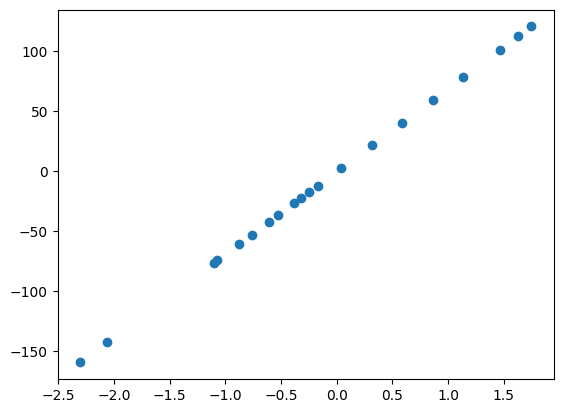

In [12]:
plt.figure()
plt.scatter(x, y)
plt.show()

In [13]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self):
        self.b0 = 0
        self.b1 = 0

    def predict(self, x):
        return self.b0 + self.b1 * x

    def error(self, X, Y):    
        return sum((self.predict(X) - Y)**2) / (2 * len(X)) 
    
    def fit(self, X, Y):  
        alpha = 0.1
        dJ0 = sum(self.predict(X) - Y) /len(X)
        dJ1 = sum((self.predict(X) - Y) * X) /len(X)
        self.b0 -= alpha * dJ0
        self.b1 -= alpha * dJ1

In [14]:
hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.error(x, y)
print("initial error:", J)

0
0
initial error: 2937.6446095153397


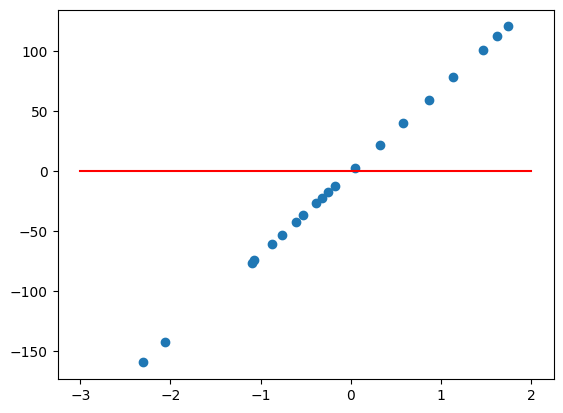

In [15]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

In [16]:
hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2253.745680891855


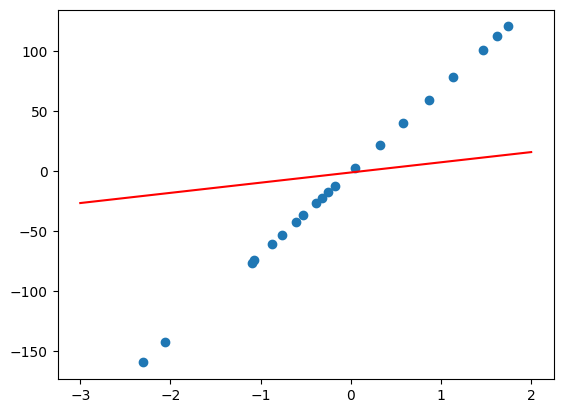

In [17]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

In [18]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, X):
        return self.b0 + self.b1 * X
    def error(self, X, Y):
        return sum(((self.predict(X) - Y)**2) / (2 * len(X)))
    def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0        
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y) /len(X)
            dJ1 = sum((self.predict(X) - Y) * X) /len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1    
            new_err = hyp.error(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
        return steps, errors

In [19]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2.776975306056007e-06


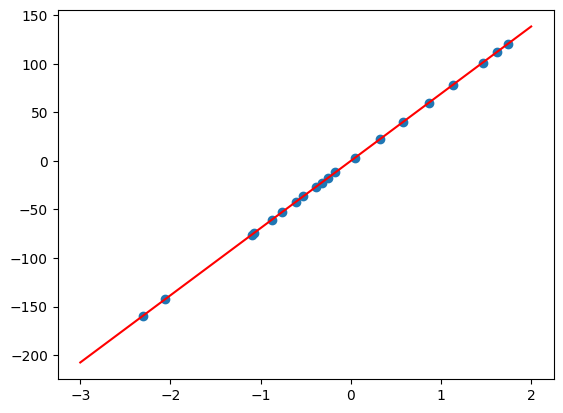

In [20]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

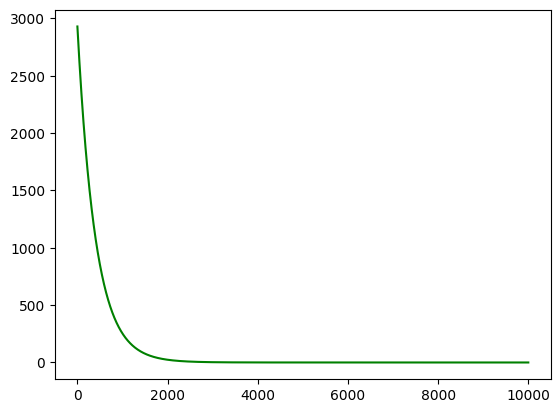

In [21]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

# Задание для самостоятелного решения

## Задание 1: Разные начальные значения параметров

In [22]:
# Проверяем сходимость при разных начальных b0, b1
for b0_init, b1_init in [(0, 0), (10, -10), (100, 100), (-50, 50)]:
    m = Model()
    m.b0, m.b1 = b0_init, b1_init
    m.fit(x, y)
    print(f"init=({b0_init:>4}, {b1_init:>4}) -> b0={m.b0:.4f}, b1={m.b1:.4f}, err={m.error(x,y):.2e}")

init=(   0,    0) -> b0=-0.0021, b1=69.1866, err=2.78e-06
init=(  10,  -10) -> b0=-0.0018, b1=69.1867, err=1.93e-06
init=( 100,  100) -> b0=0.0079, b1=69.1913, err=3.53e-05
init=( -50,   50) -> b0=-0.0041, b1=69.1858, err=9.38e-06


## Задания 3–7: Улучшенная модель

In [ ]:
class LinearRegression:
    """Парная линейная регрессия с адаптивным alpha и ранней остановкой."""

    def __init__(self, b0=0.0, b1=0.0):
        self.b0 = b0
        self.b1 = b1

    def _to_array(self, data):
        # Задание 3: работаем и с Series, и с DataFrame (один числовой столбец)
        if isinstance(data, pd.DataFrame):
            cols = data.select_dtypes(include=[np.number]).columns
            assert len(cols) == 1, "DataFrame должен содержать ровно один числовой столбец"
            data = data[cols[0]]
        return np.array(data, dtype=float)

    def predict(self, X):
        X = self._to_array(X)
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        X, Y = self._to_array(X), self._to_array(Y)
        return np.mean((self.predict(X) - Y) ** 2) / 2

    def fit(self, X, Y, alpha=None, tol=1e-6, max_steps=10000):
        """
        Задание 4: останавливаемся, если снижение ошибки < tol.
        Задание 5: также останавливаемся при достижении max_steps.
        Задание 6: если alpha не задан — подбираем автоматически.
        """
        X, Y = self._to_array(X), self._to_array(Y)
        n = len(X)

        # Задание 6: адаптивный alpha
        if alpha is None:
            alpha = 1.0
            self.b0, self.b1 = 0.0, 0.0
            # Уменьшаем alpha пока ошибка после первого шага не перестанет расти
            while True:
                b0_try = self.b0 - alpha * np.mean(self.predict(X) - Y)
                b1_try = self.b1 - alpha * np.mean((self.predict(X) - Y) * X)
                err_before = self.error(X, Y)
                # временно применяем шаг
                old_b0, old_b1 = self.b0, self.b1
                self.b0, self.b1 = b0_try, b1_try
                if self.error(X, Y) <= err_before:
                    break          # alpha подходит — перезапускаем с нуля
                self.b0, self.b1 = old_b0, old_b1
                alpha /= 2         # уменьшаем и пробуем снова
            self.b0, self.b1 = 0.0, 0.0  # перезапуск с нулей и найденным alpha

        steps, errors = [], []
        prev_err = self.error(X, Y)

        for step in range(1, max_steps + 1):
            dJ0 = np.mean(self.predict(X) - Y)
            dJ1 = np.mean((self.predict(X) - Y) * X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1

            curr_err = self.error(X, Y)
            steps.append(step)
            errors.append(curr_err)

            # Задание 4+5: ранняя остановка
            if abs(prev_err - curr_err) < tol:
                break
            prev_err = curr_err

        self.steps_, self.errors_ = steps, errors
        return steps, errors

    def plot(self, X, Y):
        # Задание 7: график независим от масштаба данных
        X, Y = self._to_array(X), self._to_array(Y)
        x_min, x_max = X.min(), X.max()
        margin = (x_max - x_min) * 0.05
        X0 = np.linspace(x_min - margin, x_max + margin, 200)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Данные и прямая регрессии
        axes[0].scatter(X, Y, alpha=0.6, label='данные')
        axes[0].plot(X0, self.predict(X0), 'r', label='модель')
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('Y')
        axes[0].legend()
        axes[0].set_title('Линейная регрессия')

        # Кривая обучения
        axes[1].plot(self.steps_, self.errors_, 'g')
        axes[1].set_xlabel('Шаг')
        axes[1].set_ylabel('Ошибка')
        axes[1].set_title(f'Обучение ({len(self.steps_)} шагов)')

        plt.tight_layout()
        plt.show()


b0=0.0001, b1=69.1875, err=4.18e-08, шагов=10
DataFrame: b0=0.0001, b1=69.1875


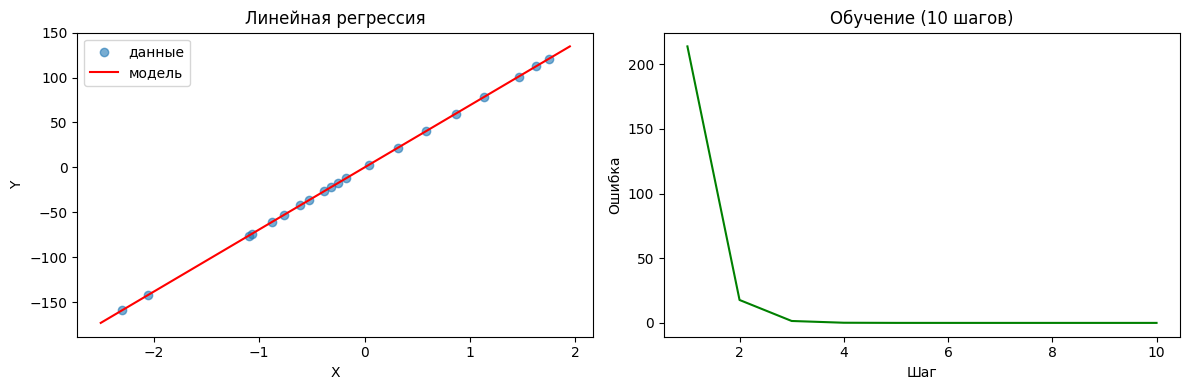

In [ ]:
# Демонстрация: обучаем с адаптивным alpha, проверяем Series и DataFrame
model = LinearRegression()
model.fit(x, y)  # alpha подбирается автоматически
print(f"b0={model.b0:.4f}, b1={model.b1:.4f}, err={model.error(x,y):.2e}, шагов={len(model.steps_)}")

# Проверка с DataFrame (задание 3)
x_df = x.to_frame()
model2 = LinearRegression()
model2.fit(x_df, y)
print(f"DataFrame: b0={model2.b0:.4f}, b1={model2.b1:.4f}")

model.plot(x, y)